# Phase 4 — Baseline Models and Cost Evaluation

This phase establishes simple reference models for the ForgeMind APS project.

The following approaches are evaluated:

1. Predict every truck as non-APS
2. Predict every truck as APS
3. Logistic Regression with leakage-safe preprocessing

Models are compared primarily using the APS business-cost function:

APS Cost = 10 × False Positives + 500 × False Negatives

Logistic Regression is evaluated using five-fold stratified out-of-fold
predictions. The official test set remains untouched.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from sklearn.pipeline import Pipeline

from src.data_loader import load_aps_data

from src.preprocessing import (
    build_linear_preprocessor,
    make_cv_splitter
    
)

In [8]:
DATA_DIR = PROJECT_ROOT / "dataset"

train_df = (
    DATA_DIR / "aps_failure_training_set.csv"
)

X,y = load_aps_data(train_df)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distributions:")
print(y.value_counts())
print(f"\nPositive rate: {y.mean():.4%}")

X shape: (60000, 170)
y shape: (60000,)

Target distributions:
class
0    59000
1     1000
Name: count, dtype: int64

Positive rate: 1.6667%


Creating the cost function

In [20]:
from src.evaluation import(
    calculate_aps_cost,
    calculate_classification_metrics,
    generate_oof_predictions
)

In [23]:
test_true = np.array([
    1,1,0,0
])

test_pred = np.array([
    1,0,1,0
])

test_result = calculate_aps_cost(
    test_true,
    test_pred
)

test_result

assert test_result["aps_cost"] == 510

print("evaluation.py imported successfully")

evaluation.py imported successfully


Algorithms


In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_pipeline = Pipeline([
    ("preprocessing",
    build_linear_preprocessor()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            random_state=42
        )
    )
])

RUN


In [25]:
X,y = load_aps_data(train_df)

In [27]:
preprocessor = build_linear_preprocessor()
cv = make_cv_splitter()

In [28]:
logistic_pipeline = Pipeline([
    ("preprocessing",
    build_linear_preprocessor()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            solver="lbfgs",
            random_state=42
        )
    )
])

In [29]:
# evaluation.py
(
    logistic_predictions,
    logisitic_probabilities,
    fold_results
) = generate_oof_predictions(
    model=logistic_pipeline,
    X=X,
    y=y,
    cv=cv,
    threshold=0.5
)

Training fold 1...


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 complete — cost=69610, time=34.27s
Training fold 2...


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 complete — cost=73810, time=36.71s
Training fold 3...


...

Fold 3 complete — cost=64890, time=43.00s
Training fold 4...


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 complete — cost=73060, time=43.38s
Training fold 5...


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 5 complete — cost=67190, time=42.23s


In [31]:
logistic_result = (
    calculate_classification_metrics(
        model_name = "Logistic Regression",
    y_true = y,
    y_pred = logistic_predictions, 
    y_probability = logistic_predictions

    )
    
)

## All-Negative Business Baseline

This strategy predicts every observation as non-APS. It achieves high
accuracy because of class imbalance, but misses every actual APS failure.

In [33]:
all_negative_predictions = np.zeros(
    len(y),
    dtype=int
)

all_negative_probabilities = np.zeros(
    len(y),
    dtype = float
)

all_negative_result = (
    calculate_classification_metrics(
        model_name = "All Negative",
        y_true=y,
        y_pred=all_negative_predictions,
        y_probability=all_negative_probabilities,
        threshold=0.5
    )
)

all_negative_result

{'model': 'All Negative',
 'threshold': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5),
 'pr_auc': np.float64(0.016666666666666666),
 'tn': 59000,
 'fp': 0,
 'fn': 1000,
 'tp': 0,
 'aps_cost': 500000,
 'cost_per_truck': 8.333333333333334}

In [34]:
assert all_negative_result["fp"] == 0
assert all_negative_result["fn"] == 1000
assert all_negative_result["aps_cost"] == 500000

## All-Positive Business Baseline

This strategy sends every truck for APS inspection. It detects all APS
failures but creates 59,000 unnecessary inspections.

In [37]:
all_positive_predictions = np.zeros(
    len(y),
    dtype=int
)

all_postitive_probabilities = np.zeros(
    len(y),
    dtype = float
)

all_positive_result = (
    calculate_classification_metrics(
        model_name = "All Positive",
        y_true=y,
        y_pred=all_positive_predictions,
        y_probability=all_postitive_probabilities,
        threshold=0.5
    )
)

all_positive_result

{'model': 'All Positive',
 'threshold': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5),
 'pr_auc': np.float64(0.016666666666666666),
 'tn': 59000,
 'fp': 0,
 'fn': 1000,
 'tp': 0,
 'aps_cost': 500000,
 'cost_per_truck': 8.333333333333334}

Fold Level Results

In [40]:
fold_results

,model,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,aps_cost,cost_per_truck,fold,validation_rows,positive_rate,training_seconds
0,Fold 1,0.5,0.076849,0.400,0.128928,0.530977,0.350026,10839,961,120,80,69610,5.800833,1,12000,0.016667,34.265161
1,Fold 2,0.5,0.051425,0.415,0.091510,0.554703,0.341878,10269,1531,117,83,73810,6.150833,2,12000,0.016667,36.707815
2,Fold 3,0.5,0.090072,0.440,0.149533,0.565050,0.351753,10911,889,112,88,64890,5.407500,3,12000,0.016667,42.997362
3,Fold 4,0.5,0.050827,0.430,0.090909,0.557740,0.368772,10194,1606,114,86,73060,6.088333,4,12000,0.016667,43.380584
4,Fold 5,0.5,0.087185,0.415,0.144097,0.548507,0.323123,10931,869,117,83,67190,5.599167,5,12000,0.016667,42.232866


In [41]:
fold_results[
    [
        "fold",
        "validation_rows",
        "positive_rate",
        "precision",
        "recall",
        "f1",
        "fp",
        "fn",
        "aps_cost",
        "training_seconds"
    ]
]

,fold,validation_rows,positive_rate,precision,recall,f1,fp,fn,aps_cost,training_seconds
0,1,12000,0.016667,0.076849,0.400,0.128928,961,120,69610,34.265161
1,2,12000,0.016667,0.051425,0.415,0.091510,1531,117,73810,36.707815
2,3,12000,0.016667,0.090072,0.440,0.149533,889,112,64890,42.997362
3,4,12000,0.016667,0.050827,0.430,0.090909,1606,114,73060,43.380584
4,5,12000,0.016667,0.087185,0.415,0.144097,869,117,67190,42.232866


In [44]:
assert len(logistic_predictions) == len(y)
assert len(logisitic_probabilities) == len(y)

assert np.all(
    (logisitic_probabilities >= 0)
    & (logisitic_probabilities <= 1)
)

print("Out-of-fold predictions validated.")

Out-of-fold predictions validated.


Results

In [47]:
phase4_results = pd.DataFrame([
    all_negative_result,
    all_positive_result,
    logistic_result
])


Overall Model Comparisons

In [48]:
result_columns = [
    "model",
    "threshold",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "tn",
    "fp",
    "tp",
    "aps_cost",
    "cost_per_truck"
]

phase4_results = (
    phase4_results[result_columns]
    .sort_values(
        by="aps_cost",
        ascending=True
    )
    .reset_index(drop=True)
)

phase4_results

,model,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,tp,aps_cost,cost_per_truck
0,Logistic Regression,0.5,0.066922,0.42,0.115448,0.660373,0.037774,53144,5856,420,348560,5.809333
1,All Negative,0.5,0.000000,0.00,0.000000,0.500000,0.016667,59000,0,0,500000,8.333333
2,All Positive,0.5,0.000000,0.00,0.000000,0.500000,0.016667,59000,0,0,500000,8.333333


Confusion Matrix

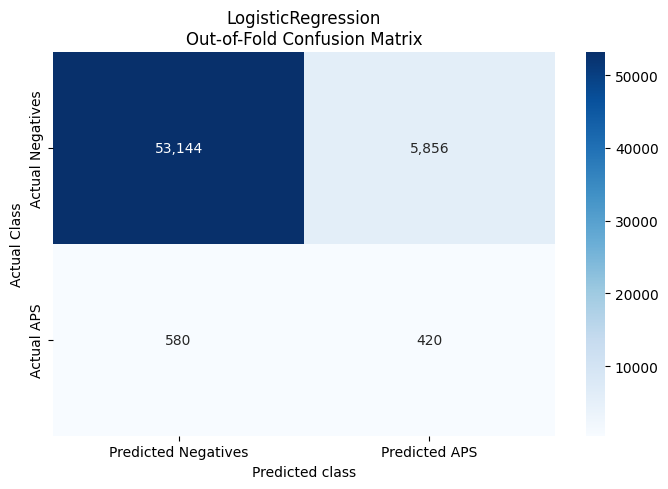

In [54]:
from cProfile import label
from sklearn.metrics import confusion_matrix
logistic_matrix = confusion_matrix(
    y,
    logistic_predictions,
    labels=[0,1]
)

plt.figure(figsize = (7,5))

sns.heatmap(
    logistic_matrix,
    annot = True,
    fmt = ",",
    cmap = "Blues",
    xticklabels=[
        "Predicted Negatives",
        "Predicted APS"
    ],
    yticklabels=[
        "Actual Negatives",
        "Actual APS"
    ]
)

plt.title(
    "LogisticRegression\n"
    "Out-of-Fold Confusion Matrix"
)

plt.xlabel("Predicted class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

APS cost comparison

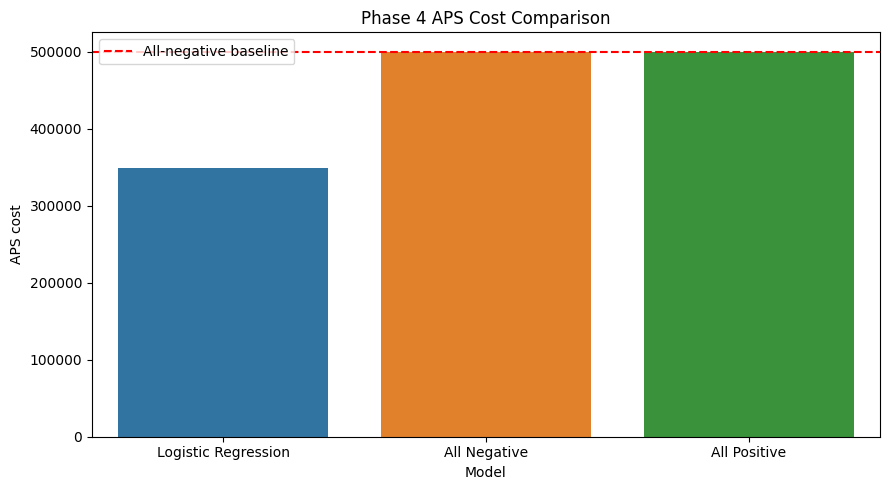

In [52]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=phase4_results,
    x="model",
    y="aps_cost",
    hue="model",
    legend=False
)

plt.axhline(
    y=500000,
    color="red",
    linestyle="--",
    label="All-negative baseline"
)

plt.title("Phase 4 APS Cost Comparison")
plt.xlabel("Model")
plt.ylabel("APS cost")
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fold_results.to_csv(
    RESULTS_DIR
    / "phase4_logistic_fold_results.csv",
    index=False
)

print("Phase 4 results saved.")

Phase 4 results saved.
